# A sharded training step

Start a fresh kernel, then Run all: the first cell configures 4 logical CPU devices before backend initialization. They share one physical CPU; this is sharding practice, not TPU performance emulation. TPU execution not validated.

- Derive the global mean loss and gradient.
- Specify aligned data and replicated parameter placement.
- Verify sharded updates against independent host arithmetic.
- Diagnose normalization errors in equal and unequal local batches.

If we split a batch across four devices, should the model learn four times as much in one step? It should still follow the same global loss. We’ll compare a sharded regression update with a formula we can check on the host, then reproduce the scaling mistake caused by summing local mean gradients.

## The idea

A sharded training step must preserve the intended global objective. Local reductions and collective operations should produce the same normalized gradient as an unsharded reference on the same examples.

## Derive the global denominator

One shard has two examples with mean gradient $1$; another has one example with gradient $4$. The global mean is $(2+4)/3=2$. Averaging the local means gives $2.5$, overweighting the small shard.

Carry contributions and counts so the final denominator matches the objective. With masked sequence losses, count valid targets rather than automatically counting devices or sequences.

The matching gradient bars are an important check on the current fixture. Add unequal valid counts to expose a weighting rule that balanced shards could hide. Numerical agreement should be tested where the implementation's assumptions are most vulnerable.

### Pause and reason

Which test exposes an incorrect average of local means?

<details><summary>Compare your reasoning</summary>

Use unequal example or valid-token counts per shard and compare with an independently calculated global mean.

</details>

## Write the objective before splitting the data

Our model predicts $Xw$ with two weights and no bias. The synthetic labels use true weights $[2,-1]$, but the initial weights are zero. The squared-error loss averages eight residuals. Its gradient is $\frac{2}{N}X^\mathsf{T}r$, where $r=Xw-y$ and $N=8$. This host formula is independent of JAX autodiff and supplies a useful reference for the first update.

At $w=0$ the targets are $[2,-1,1,4,-2,3,0,2]$. Squared targets sum to $39$, so initial loss is $39/8=4.875$. $X^\mathsf{T}y=[21,3]$, so the gradient is $[-5.25,-0.75]$. With learning rate $0.1$ the new weights are $[0.525,0.075]$. Check these values before looking at a training curve.

$$
\begin{aligned}L(w)&=\frac{1}{8}\sum_{i=1}^{8}(x_i^\mathsf{T}w-y_i)^2\\g&=\frac{2}{8}X^\mathsf{T}(Xw-y)\\w_{\mathrm{next}}&=w-0.1g\end{aligned}
$$

## Give batch and parameters different placements

The feature matrix has shape $(8,2)$ and uses `P("data",None)`; each of four devices owns two examples. Labels have shape $(8,)$ and use `P("data")`, so their shards align with the feature rows. Parameters have shape $(2,)$ and use `P()`, giving every device both weights.

The input sharding tree supplied to jit has one entry per argument. Outputs are weights, scalar loss and a two-element gradient; all three are replicated in this small example. Replication does not mean four independently trained models. The replicas represent the same global parameters and must receive the same global update.

```text
CPU 0: X rows 0:2, y rows 0:2, full w
CPU 1: X rows 2:4, y rows 2:4, full w
CPU 2: X rows 4:6, y rows 4:6, full w
CPU 3: X rows 6:8, y rows 6:8, full w
partial contributions → global gradient → same w_next
```

## Differentiate the global function rather than inventing a local objective

loss operates on global JAX arrays. value_and_grad evaluates the objective and obtains its parameter derivative together. jit compiles that function with explicit placement contracts; you do not call a Python training loop separately on each device. Combining contributions is necessary because each local batch alone cannot determine the global mean gradient.

This lesson uses automatic global-array parallelization, not manual shard_map or an explicit pmean. The compiler arranges required operations. Do not add an extra collective to an already global reduction merely because the input is sharded. If you later implement a manual local program, you must derive its aggregation and normalization from the same objective.

## A correct first update is stronger evidence than a falling curve

A loss curve can decrease even with a normalization bug, especially at a small learning rate. Compare the initial loss, every gradient component and updated weights with NumPy. Then change the batch contents and order: a correct global mean should not depend on which device receives a row. Check replicated weight shards separately.

A ten-step loop is included as a transfer experiment, but this is not a complete resilient training system. It has no data pipeline, optimizer moments, checkpoint or multi-host failure handling. CPU virtual devices demonstrate placement and numerical equivalence; accelerator efficiency requires measurement on that accelerator. Float32 reduction order may differ, so use stated tolerances instead of bitwise comparisons.

## Start a fresh CPU runtime

Create main.py in your course workspace. Paste this block first. If using a notebook, restart its kernel before running any cell.

In [1]:
import jax
# Run this file in a fresh process; in a notebook restart the kernel first.
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_num_cpu_devices", 4)
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
devices = jax.devices("cpu")
if len(devices) != 4:
    raise RuntimeError("Expected four CPU devices. Restart the notebook kernel, then Run all; do not run an earlier JAX cell first.")
mesh = Mesh(np.array(devices), ("data",))
rows = NamedSharding(mesh, P("data", None))
replicated = NamedSharding(mesh, P())

Configuration happens before `devices()` or array creation initializes a backend. This file explicitly chooses CPU even on a GPU machine.

## Place and compute

Append this block in the same file. Predict the shapes and values before running.

In [2]:
host_x = np.array([[1,0],[0,1],[1,1],[2,0],[0,2],[2,1],[1,2],[2,2]],dtype=np.float32)
true_w = np.array([2.,-1.],dtype=np.float32)
host_y = host_x @ true_w
labels_sharding = NamedSharding(mesh,P("data"))
x = jax.device_put(host_x, rows)
y = jax.device_put(host_y, labels_sharding)
w = jax.device_put(np.zeros(2,dtype=np.float32),replicated)
def loss(weights, features, labels):
    return jnp.mean((features @ weights-labels)**2)
def update(weights, features, labels):
    value, gradient = jax.value_and_grad(loss)(weights,features,labels)
    return weights - 0.1*gradient, value, gradient
train_step = jax.jit(update, in_shardings=(replicated,rows,labels_sharding),out_shardings=(replicated,replicated,replicated))
new_w, before, gradient = train_step(w,x,y)

Mesh axis names describe placement. They are separate from the numerical array dimensions.

## Inspect and verify

Append the checks, save the file and run python main.py with the setup lesson environment.

In [3]:
expected_gradient = 2 * host_x.T @ (-host_y) / len(host_y)
np.testing.assert_allclose(np.asarray(gradient),expected_gradient,rtol=1e-6,atol=1e-6)
np.testing.assert_allclose(np.asarray(new_w),-0.1*expected_gradient,rtol=1e-6,atol=1e-6)
expected_loss = np.mean(host_y**2)
np.testing.assert_allclose(np.asarray(before), expected_loss,rtol=1e-6)
assert float(loss(new_w,x,y)) < float(before)
for shard in new_w.addressable_shards:
    np.testing.assert_allclose(np.asarray(shard.data),np.asarray(new_w))
print("Initial loss:",float(before))
print("Gradient:",np.asarray(gradient),"updated weights:",np.asarray(new_w))
print("Updated loss:",float(loss(new_w,x,y)))

Initial loss: 4.875
Gradient: [-5.25 -0.75] updated weights: [0.52500004 0.075     ]
Updated loss: 2.6784372329711914


Assertions compare against host calculations or hand-derived values; printing a sharding object alone does not establish correctness.

## Run the example

In [4]:
import jax
# Run this file in a fresh process; in a notebook restart the kernel first.
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_num_cpu_devices", 4)
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
devices = jax.devices("cpu")
if len(devices) != 4:
    raise RuntimeError("Expected four CPU devices. Restart the notebook kernel, then Run all; do not run an earlier JAX cell first.")
mesh = Mesh(np.array(devices), ("data",))
rows = NamedSharding(mesh, P("data", None))
replicated = NamedSharding(mesh, P())

host_x = np.array([[1,0],[0,1],[1,1],[2,0],[0,2],[2,1],[1,2],[2,2]],dtype=np.float32)
true_w = np.array([2.,-1.],dtype=np.float32)
host_y = host_x @ true_w
labels_sharding = NamedSharding(mesh,P("data"))
x = jax.device_put(host_x, rows)
y = jax.device_put(host_y, labels_sharding)
w = jax.device_put(np.zeros(2,dtype=np.float32),replicated)
def loss(weights, features, labels):
    return jnp.mean((features @ weights-labels)**2)
def update(weights, features, labels):
    value, gradient = jax.value_and_grad(loss)(weights,features,labels)
    return weights - 0.1*gradient, value, gradient
train_step = jax.jit(update, in_shardings=(replicated,rows,labels_sharding),out_shardings=(replicated,replicated,replicated))
new_w, before, gradient = train_step(w,x,y)

expected_gradient = 2 * host_x.T @ (-host_y) / len(host_y)
np.testing.assert_allclose(np.asarray(gradient),expected_gradient,rtol=1e-6,atol=1e-6)
np.testing.assert_allclose(np.asarray(new_w),-0.1*expected_gradient,rtol=1e-6,atol=1e-6)
expected_loss = np.mean(host_y**2)
np.testing.assert_allclose(np.asarray(before), expected_loss,rtol=1e-6)
assert float(loss(new_w,x,y)) < float(before)
for shard in new_w.addressable_shards:
    np.testing.assert_allclose(np.asarray(shard.data),np.asarray(new_w))
print("Initial loss:",float(before))
print("Gradient:",np.asarray(gradient),"updated weights:",np.asarray(new_w))
print("Updated loss:",float(loss(new_w,x,y)))

Initial loss: 4.875
Gradient: [-5.25 -0.75] updated weights: [0.52500004 0.075     ]
Updated loss: 2.6784372329711914


Expected: Initial loss $4.875$; gradient $[-5.25,-0.75]$; weights $[0.525,0.075]$; updated loss is lower. Small float32 printing differences are expected.

## Sharded differentiation matches the global reference

Predict: Should placing examples on different devices change the gradient?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'bar', 'labels': ['weight 0', 'weight 1'], 'ylabel': 'gradient coordinate', 'series': [{'label': 'sharded JAX', 'y': np.asarray(gradient).tolist()}, {'label': 'NumPy reference', 'y': expected_gradient.tolist()}]}

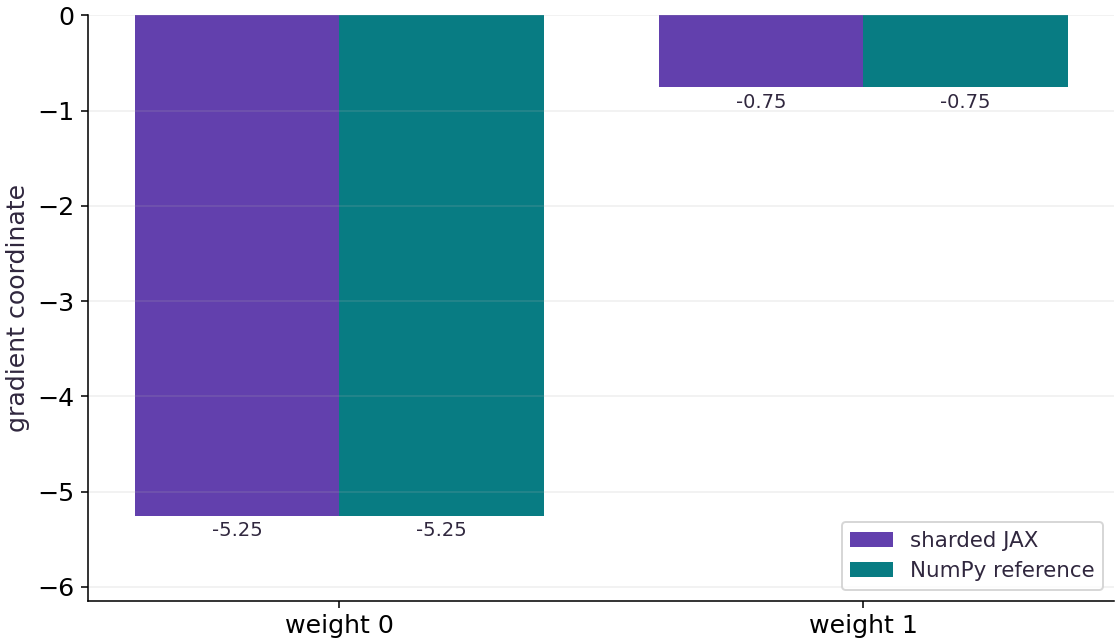

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

For each weight coordinate, compare the sharded JAX gradient with the NumPy reference gradient beside it. Both methods give approximately $(-5.25,-0.75)$, so the paired bars have equal heights. They remain separate bars even where their edges touch.

The bars extend below zero because the derivatives are negative. This is not a plot of negative loss. The larger magnitude for weight $0$ indicates a stronger local sensitivity of the loss to that coordinate.

### Connect it to the computation

A gradient descent step subtracts these values. From zero weights with rate $0.1$, the next weights would be $(0.525,0.075)$. This connects the signs in the picture to an actual update rather than treating taller or shorter bars as inherently better.

Agreement with the global reference checks that sharding and reduction preserved the intended gradient on this batch. It does not establish a speedup, or imply that a coordinate’s current gradient sign reveals its final optimal weight. Input correlations and subsequent updates can change that sign.

## Permutation across shards

Predict: Reversing example order changes which device owns each example. Should the global gradient change?

In [7]:
reverse_x = jax.device_put(host_x[::-1].copy(),rows)
reverse_y = jax.device_put(host_y[::-1].copy(),labels_sharding)
reverse_w,reverse_loss,reverse_gradient = train_step(w,reverse_x,reverse_y)
np.testing.assert_allclose(np.asarray(reverse_gradient),expected_gradient,rtol=1e-6,atol=1e-6)
np.testing.assert_allclose(np.asarray(reverse_w),np.asarray(new_w),rtol=1e-6,atol=1e-6)
print("Permutation preserves the global update")

Permutation preserves the global update


Expected: Gradient and update agree within $10^{-6}$.

The global mean is invariant to row order. This check exposes accidental dependence on a particular local subset.

## Ten updates against a host training loop

Predict: Predict whether the two implementations should track each other, not whether loss reaches zero in ten steps.

In [8]:
cpu_weights = w
reference_weights = np.zeros(2,dtype=np.float32)
for step_index in range(10):
    cpu_weights,_,_ = train_step(cpu_weights,x,y)
    residual = host_x @ reference_weights-host_y
    reference_weights -= 0.1*(2*host_x.T @ residual/len(host_y))
    np.testing.assert_allclose(np.asarray(cpu_weights),reference_weights,rtol=1e-5,atol=1e-6)
print("Ten-step weights:",np.asarray(cpu_weights))

Ten-step weights: [ 1.704636  -0.7047408]


Expected: Each of ten parameter updates agrees with the independent host loop within the stated tolerance.

Checking every update catches transient mismatches that a single final loss comparison could hide.

## Your exercise

Run a changed target/initial-state update, then diagnose the factor-of-four local-mean bug and repair uneven-batch aggregation.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
changed_y = host_x @ np.array([-1.,3.],dtype=np.float32)
start = np.array([0.2,-0.1],dtype=np.float32)
def changed_update(weights,features,labels):
    return weights-0.05*jax.grad(loss)(weights,features,labels)
changed_step = jax.jit(changed_update,in_shardings=(replicated,rows,labels_sharding),out_shardings=replicated)
result = changed_step(jax.device_put(start,replicated),x,jax.device_put(changed_y,labels_sharding))
reference_gradient = 2*host_x.T @ (host_x@start-changed_y)/len(changed_y)
np.testing.assert_allclose(np.asarray(result),start-0.05*reference_gradient,rtol=1e-6,atol=1e-6)

local_gradients = []
for features,labels in zip(np.split(host_x,4),np.split(host_y,4)):
    local_gradients.append(2*features.T @ (-labels)/len(labels))
wrong = np.sum(local_gradients,axis=0)
right = np.mean(local_gradients,axis=0)
np.testing.assert_allclose(wrong,4*expected_gradient,rtol=1e-6)
np.testing.assert_allclose(right,expected_gradient,rtol=1e-6)
# Unequal partitions: weight local mean gradients by their observation counts.
parts = [(host_x[:3],host_y[:3]),(host_x[3:],host_y[3:])]
weighted = sum(len(b)*(2*a.T @ (-b)/len(b)) for a,b in parts)/len(host_y)
np.testing.assert_allclose(weighted,expected_gradient,rtol=1e-6)
print("Summed local means are four times too large; weighted aggregation repaired")

Summed local means are four times too large; weighted aggregation repaired


## Transfer to a different target model · Challenge

Change true weights to $[-1,3]$, start at $[0.2,-0.1]$ and use learning rate $0.05$. Derive and check the new update without reusing the original numeric answer.

Hint: The original train_step hardcodes $0.1$; define a new step with the changed rate.

In [11]:
# Write your attempt here.

## Reference reasoning

The independent formula follows the new target, initial state and learning rate. Reusing a hard-coded expected weight vector would not test transfer.

In [12]:
changed_y = host_x @ np.array([-1.,3.],dtype=np.float32)
start = np.array([0.2,-0.1],dtype=np.float32)
def changed_update(weights,features,labels):
    return weights-0.05*jax.grad(loss)(weights,features,labels)
changed_step = jax.jit(changed_update,in_shardings=(replicated,rows,labels_sharding),out_shardings=replicated)
result = changed_step(jax.device_put(start,replicated),x,jax.device_put(changed_y,labels_sharding))
reference_gradient = 2*host_x.T @ (host_x@start-changed_y)/len(changed_y)
np.testing.assert_allclose(np.asarray(result),start-0.05*reference_gradient,rtol=1e-6,atol=1e-6)

## Diagnose summed local means · Challenge

Compute four host local mean gradients. Show why summing them gives four times the global mean, then repair the aggregation. Also explain the unequal-batch generalization.

Hint: A mean of equal-size local means works; unequal sizes require weighting by local counts.

In [13]:
# Write your attempt here.

## Reference reasoning

Each local gradient already divides by its local count. Summing four equal local means omits division by four. For unequal counts, an unweighted mean also misrepresents examples; sum count-weighted local means and divide by total count.

In [14]:
local_gradients = []
for features,labels in zip(np.split(host_x,4),np.split(host_y,4)):
    local_gradients.append(2*features.T @ (-labels)/len(labels))
wrong = np.sum(local_gradients,axis=0)
right = np.mean(local_gradients,axis=0)
np.testing.assert_allclose(wrong,4*expected_gradient,rtol=1e-6)
np.testing.assert_allclose(right,expected_gradient,rtol=1e-6)
# Unequal partitions: weight local mean gradients by their observation counts.
parts = [(host_x[:3],host_y[:3]),(host_x[3:],host_y[3:])]
weighted = sum(len(b)*(2*a.T @ (-b)/len(b)) for a,b in parts)/len(host_y)
np.testing.assert_allclose(weighted,expected_gradient,rtol=1e-6)
print("Summed local means are four times too large; weighted aggregation repaired")

Summed local means are four times too large; weighted aggregation repaired


## Checkpoint

Four equal-size shards compute local mean gradients. Which aggregation gives the global mean gradient?

1. Sum them without scaling.
2. Average them, or sum local gradient numerators and divide by total examples.
3. Choose the device with the lowest local loss.

## Diagnose

Each local gradient already divides by its local count. Summing four equal local means omits division by four. For unequal counts, an unweighted mean also misrepresents examples; sum count-weighted local means and divide by total count.

## Evidence

Each local gradient already divides by its local count. Summing four equal local means omits division by four. For unequal counts, an unweighted mean also misrepresents examples; sum count-weighted local means and divide by total count.

## Carry forward

- Write the objective before splitting the data
- Give batch and parameters different placements
- Differentiate the global function rather than inventing a local objective
- A correct first update is stronger evidence than a falling curve

## Primary references

- [JAX CPU device configuration (set before initialization)](https://docs.jax.dev/en/latest/config_options.html#num-cpu-devices)
- [Distributed arrays and automatic parallelization](https://docs.jax.dev/en/latest/201/sharding.html)